In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))

In [2]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [3]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/job_array/'
with h5py.File(dir2+'lagrangian_binary_array.h5', 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [4]:
#job array setup #UNCOMMENT IF USING JOB_ARRAY
num_jobs=60 #how many total jobs are being run? i.e. array=1-100 ==> num_jobs=100 #***
job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0)) #this is the current SBATCH job id
if job_id==0: job_id=30
    
num_parcels=len(data['time']) #total num of variables
job_range = num_parcels//num_jobs #number of parcels per job 
start_job = (job_id - 1) * job_range
end_job = start_job + job_range
if job_id==num_jobs: end_job=num_parcels-1


#FOR ENTRAINMENT THE PREVIOUS TIMESTEP IS ALWAYS NEEDED, SO SLICED WILL CAUSE WRAP AROUND DATA
#INSTEAD NP.WHERE RESULTS MUST BE SUBSETTED
# data=data.isel(time=slice(start_job,end_job))
# parcel=parcel.isel(time=slice(start_job,end_job))

# #SLICING LAGRANGIAN BINARY ARRAY
# A_g=A_g[slice(start_job,end_job)]
# A_c=A_c[slice(start_job,end_job)]
# Z=Z[slice(start_job,end_job)]
# Y=Y[slice(start_job,end_job)]
# X=X[slice(start_job,end_job)]

In [7]:
###########################################################################################################################################################################

In [8]:
#ENTRAINMENT/DETRAINMENT
########################################################################################################

In [ ]:
#constants
Cp=1004 #Jkg-1K-1
Cv=717 #Jkg-1K-1
Rd=Cp-Cv #Jkg-1K-1
eps=0.608

Lx=data['xf'][-1].item()-data['xf'][0].item() #x length (km)
Ly=data['yf'][-1].item()-data['yf'][0].item() #y length (km)
Np=len(parcel['xh']) #number of lagrangian parcles
dt=data['time'][1].item()/1e9 #sec
dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
xs=data['xf'].values*1000
ys=data['yf'].values*1000
zs=data['zf'].values*1000

def zf(z):
    k=z #z is the # level of z
    out=data['zf'].values[k]*1000
    return out
# def rho(x,y,z,t):
#     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
#     p0=101325 #Pa
#     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
#     T=theta*(p/p0)**(Rd/Cp)
#     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
#     # Tv=T*(1+eps*qv)
#     Tv=T*(eps+qv)/(eps*(1+qv))
#     rho = p/(Rd*Tv)
#     out=rho
#     return out
rho_data=data['rho'].data
def rho(x,y,z,t):
    # out=data['rho'].isel(xh=x,yh=y,zh=z,time=t).item()
    out=rho_data[t,z,y,x]
    return out
def m(t):
    m=0
    #triple sum
    for k in range(len('zh')):
        for j in range(len('yh')):
            for i in range(len('xh')):
                rho_out=rho(i,j,k,t)
                m+=rho_out*(zf(k+1)-zf(k))
    #triple sum
    m=m*dx*dy/Np
    out=m
    return out

In [ ]:
def ed(A,z,t,type):
    #Get Z Locations
    zs=Z[t,:]
    
    #Essential A_t-A_(t-1)
    D=A[t,:]-A[t-1,:]
    
    #Essentially the I function
    z_ind=np.where(zs==z)
    A_z=D[z_ind]
    
    #Esentially the H function

    if type=='e':
        A_z[A_z<0]=0 #entrainment
    if type=='d':
        A_z[A_z>0]=0 #detrainment

    #Essentially the sumnation
    A_sum=np.sum(A_z)

    if type=='d': 
        A_sum*=-1

    #CONSTANT
    ############
    m_out=m(t)
    dz=zf(z+1)-zf(z)
    constant=(m_out/Lx/Ly/dz/dt) 
    # constant=1
    A_sum*=constant
    return A_sum

#creates 2d storage array
tlen=len(data['time'])
zlen=len(data['zh'])
profile_array_e_g=np.zeros((tlen,zlen))
profile_array_d_g=np.zeros((tlen,zlen))
profile_array_e_c=np.zeros((tlen,zlen))
profile_array_d_c=np.zeros((tlen,zlen))

#Adding to Profile Array
import itertools
ts = range(0, len(data['time']))  # ts from 0 to 140
zs = range(0, len(data['zh']))   # zs from 0 to 34
for count, (t, z) in enumerate(itertools.product(ts, zs)):
    if np.mod(count,10000)==0: print(f'{count*100/len(ts):.2f}%')

    #GENERAL
    A_sum_g=ed(A_g, z,t,type='e')
    profile_array_e_g[t,z]+=A_sum_g
    A_sum_g=ed(A_g, z,t,type='d')
    profile_array_d_g[t,z]+=A_sum_g

    #CLOUDY
    A_sum_c=ed(A_c, z,t,type='e')
    profile_array_e_c[t,z]+=A_sum_c
    A_sum_c=ed(A_c, z,t,type='d')
    profile_array_d_c[t,z]+=A_sum_c

#SAVING
dir3=dir+'Project_Algorithms/Entrainment/2D_entrainmentdetrainment_profiles.h5'
with h5py.File(dir3, "w") as h5f:
    h5f.create_dataset("profile_array_e_g", data=profile_array_e_g)
    h5f.create_dataset("profile_array_e_c", data=profile_array_e_c)
    h5f.create_dataset("profile_array_d_g", data=profile_array_d_g)
    h5f.create_dataset("profile_array_d_c", data=profile_array_d_c)

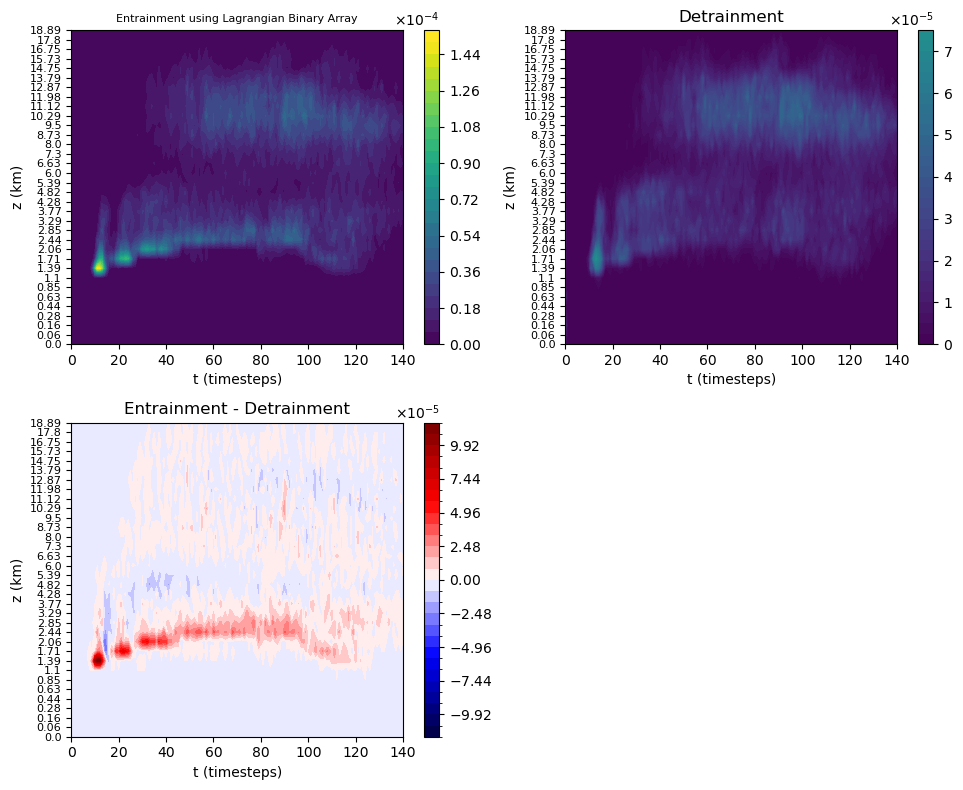

In [23]:
type='general'
type='cloudy'

dir3=dir+'Project_Algorithms/Entrainment/2D_entrainmentdetrainment_profiles.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_e_g = h5f["profile_array_e_g"][:]
    profile_array_e_c = h5f["profile_array_e_c"][:]
    profile_array_d_g = h5f["profile_array_d_g"][:]
    profile_array_d_c = h5f["profile_array_d_c"][:]

if type=='general':
    profile_array_e=profile_array_e_g
    profile_array_d=profile_array_d_g
if type=='cloudy':
    profile_array_e=profile_array_e_c
    profile_array_d=profile_array_d_c


import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, figure=fig)

######
cmap1 = plt.cm.viridis
cmap2 = plt.cm.seismic 
n_levels=29
######

######
vmax_shared = np.max([np.max(profile_array_e), np.max(profile_array_d)])
norm_shared = mcolors.Normalize(vmin=0, vmax=vmax_shared)
######

# First subplot: Entrainment
########################################
ax1 = fig.add_subplot(gs[0, 0])
# contour1 = ax1.contourf(profile_array_e.T, cmap=cmap1)
contour1 = ax1.contourf(profile_array_e.T, cmap=cmap1, norm=norm_shared, levels=n_levels)
cbar1=fig.colorbar(contour1, ax=ax1)
Nz = len(data['zh'])
ax1.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax1.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax1.set_ylabel('z (km)');ax1.set_xlabel('t (timesteps)')
ax1.set_title('Entrainment using Lagrangian Binary Array',fontsize=8)

# Second subplot: Detrainment
########################################
ax2 = fig.add_subplot(gs[0, 1])
# contour2 = ax2.contourf(profile_array_d.T, cmap=cmap1)
contour2 = ax2.contourf(profile_array_d.T, cmap=cmap1, norm=norm_shared, levels=n_levels)
cbar2 = fig.colorbar(contour2, ax=ax2)
ax2.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax2.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax2.set_ylabel('z (km)');ax2.set_xlabel('t (timesteps)')
ax2.set_title('Detrainment')

# Third subplot: Net Entrainment
########################################
profile_array_net=profile_array_e-profile_array_d

# #OLD METHOD, DOESNT BALANCE COLOR LEVELS
# # Normalize with a balanced vmin and vmax
# levels=49; vmin=np.min(profile_array_net);vmax=np.max(profile_array_net)
# # vmin=-np.max(abs(profile_array_net)); vmax=+np.max(abs(profile_array_net))
# norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# Normalize with a balanced vmin and vmax
vmin=-np.max(abs(profile_array_net)); vmax=+np.max(abs(profile_array_net))
levels = np.linspace(vmin, vmax, n_levels)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)
cmap = plt.get_cmap('RdBu_r', n_levels)

ax3 = fig.add_subplot(gs[1, 0])
contour3 = ax3.contourf((profile_array_net).T, cmap=cmap2, norm=norm, levels=levels)
# contour3 = ax3.contourf((profile_array_net).T, cmap=cmap2, levels=30,vmin=-np.max(abs(profile_array_net)), vmax=+np.max(abs(profile_array_net)))
# cmap2 = plt.get_cmap('RdBu', 29);contour3 = ax3.pcolor(profile_array_net.T, cmap=cmap2, norm=norm, shading='auto')
cbar3 = fig.colorbar(contour3, ax=ax3, norm=norm)

#FIXING TICKS
ax3.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax3.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax3.set_ylabel('z (km)');ax3.set_xlabel('t (timesteps)')
ax3.set_title('Entrainment - Detrainment')

#FIXING SCIENTIFIC NOTATION
from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2))  # Adjust the range for scientific notation
for cbar in (cbar1,cbar2, cbar3):  # These must be Colorbar instances
    cbar.formatter = formatter
    cbar.update_ticks()

# Display the plot
plt.tight_layout()

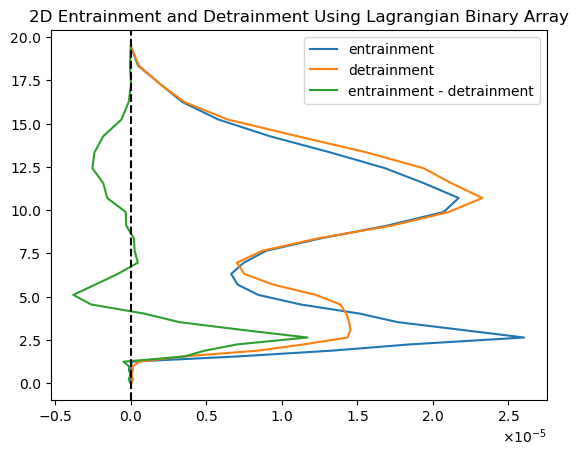

In [4]:
plt.plot(np.mean(profile_array_e,axis=(0)),data['zh'],label='entrainment')
plt.plot(np.mean(profile_array_d,axis=(0)),data['zh'],label='detrainment')
plt.plot(np.mean(profile_array_e-profile_array_d,axis=(0)),data['zh'],label='entrainment - detrainment')
plt.axvline(0,color='k',linestyle='dashed')

plt.legend(); plt.title('2D Entrainment and Detrainment Using Lagrangian Binary Array')

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
plt.gca().xaxis.set_major_formatter(formatter)

In [21]:
############## 3D ENTRAINMENT

In [139]:
#constants
Cp=1004 #Jkg-1K-1
Cv=717 #Jkg-1K-1
Rd=Cp-Cv #Jkg-1K-1
eps=0.608

Lx=data['xf'][-1].item()-data['xf'][0].item() #x length (km)
Ly=data['yf'][-1].item()-data['yf'][0].item() #y length (km)
Np=len(parcel['xh']) #number of lagrangian parcles
dt=data['time'][1].item()/1e9 #sec
dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
xs=data['xf'].values*1000
ys=data['yf'].values*1000
zs=data['zf'].values*1000

def zf(z):
    k=z #z is the # level of z
    out=data['zf'].values[k]*1000
    return out
# def rho(x,y,z,t):
#     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
#     p0=101325 #Pa
#     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
#     T=theta*(p/p0)**(Rd/Cp)
#     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
#     # Tv=T*(1+eps*qv)
#     Tv=T*(eps+qv)/(eps*(1+qv))
#     rho = p/(Rd*Tv)
#     out=rho
#     return out
rho_data=data['rho'].data
def rho(x,y,z,t):
    # out=data['rho'].isel(xh=x,yh=y,zh=z,time=t).item()
    out=rho_data[t,z,y,x]
    return out
def m(t):
    m=0
    #triple sum
    for k in range(len('zh')):
        for j in range(len('yh')):
            for i in range(len('xh')):
                rho_out=rho(i,j,k,t)
                m+=rho_out*(zf(k+1)-zf(k))
    #triple sum
    m=m*dx*dy/Np
    out=m
    return out

In [138]:
def ed3d(A,t,z,y,x,type):
    #Get Z Locations
    zs=Z[t,:]
    ys=Y[t,:]
    xs=X[t,:]
    
    #Essential A_t-A_(t-1)
    D=A[t,:]-A[t-1,:]
    
    #Essentially the I function
    zyx_ind=np.where((zs==z)&(ys==y)&(xs==x))
    A_z=D[zyx_ind]
    
    #Esentially the H function

    if type=='e':
        A_z[A_z<0]=0 #entrainment
    if type=='d':
        A_z[A_z>0]=0 #detrainment

    #Essentially the sumnation
    A_sum=np.sum(A_z)

    # if type=='d': 
    #     A_sum*=-1

    #CONSTANT
    ############
    m_out=m(t)
    dz=zf(z+1)-zf(z);dy=1000;dx=1000
    constant=(m_out/dx/dy/dz/dt) 
    # constant=1
    A_sum*=constant
    return A_sum

In [140]:
#LOADING VARIABLES
if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    # variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data

    print('done loading')
    emptylike=True

In [43]:
#JOB ARRAY FOR SUBSETTING NP.WHERE OUTPUTS
def job_subset_where(where):
    array1, array2, array3, array4 = where
    mask = (array1 >= start_job) & (array1 < end_job)
    filtered_data = tuple(arr[mask] for arr in where) #USE IN INITIALIZING FULL ARRAY EACH TIME
    return filtered_data

In [65]:
#SET UP TO RUN WITH JOB_ARRAY
calc_entrain=False
calc_detrain=True

#creates 2d storage array

# tlen=len(data['time'])
tlen=end_job-start_job
zlen=len(data['zh'])
ylen=len(data['yh'])
xlen=len(data['xh'])

profile_array_e_g=np.zeros((tlen,zlen,ylen,xlen))
profile_array_d_g=np.zeros((tlen,zlen,ylen,xlen))
profile_array_e_c=np.zeros((tlen,zlen,ylen,xlen))
profile_array_d_c=np.zeros((tlen,zlen,ylen,xlen))
    
#Adding to Profile Array
# import itertools
# ts = range(0, 141)  # ts from 0 to 140
# zs = range(0, 34)   # zs from 0 to 34
# for count, (t, z) in enumerate(itertools.product(ts, zs)):

#GENERAL UPDRAFTS

#ENTRAINMENT
if calc_entrain==True:
    w_thresh1=0.1
    indices=np.where((w_data>=w_thresh1))
    indices_e=job_subset_where(indices) #USE FOR JOB_ARRAY ONLY***
    if np.any(indices_e)==True:
        tmin=np.min(indices_e[0]) #USE FOR JOB_ARRAY ONLY***
    else: 
        tmin=0
    for count, (t, z, y, x) in enumerate(zip(*indices_e)):
        if np.mod(count,10000)==0: print(f'{count*100/len(indices_e[0]):.2f}%')
        
        A_sum_e_g=ed3d(A_g,t,z,y,x,type='e')
        # profile_array_e_g[t,z,y,x]+=A_sum_e_g
        profile_array_e_g[t-tmin,z,y,x]+=A_sum_e_g #CORRECT FOR JOB_ARRAY

#DETRAINMENT
if calc_detrain==True:
    w_thresh1=0.1
    indices=np.where((w_data<w_thresh1)) #NEGATION OF THRESHOLD
    indices_d=job_subset_where(indices) #USE FOR JOB_ARRAY ONLY***
    if np.any(indices_d)==True:
        tmin=np.min(indices_d[0]) #USE FOR JOB_ARRAY ONLY***
    else: 
        tmin=0
    for count, (t, z, y, x) in enumerate(zip(*indices_d)):
        if np.mod(count,10000)==0: print(f'{count*100/len(indices_d[0]):.2f}%')
        
        A_sum_d_g=ed3d(A_g,t,z,y,x,type='d')
        # profile_array_d_g[t,z,y,x]+=A_sum_d_g
        profile_array_d_g[t-tmin,z,y,x]+=A_sum_d_g #CORRECT FOR JOB_ARRAY


#CLOUDY UPDRAFTS

#ENTRAINMENT
if calc_entrain==True:
    w_thresh2=0.5
    qcqi_thresh=1e-6
    indices=np.where((w_data>=w_thresh2)&(qc_plus_qi>=qcqi_thresh))
    indices_e=job_subset_where(indices) #USE FOR JOB_ARRAY ONLY***
    if np.any(indices_e)==True:
        tmin=np.min(indices_e[0]) #USE FOR JOB_ARRAY ONLY***
    else: 
        tmin=0
    for count, (t, z, y, x) in enumerate(zip(*indices_e)):
        if np.mod(count,10000)==0: print(f'{count*100/len(indices_e[0]):.2f}%')
            
        A_sum_e_c=ed3d(A_c,t,z,y,x,type='e')
        # profile_array_e_c[t,z,y,x]+=A_sum_e_c
        profile_array_e_c[t-tmin,z,y,x]+=A_sum_e_c #CORRECT FOR JOB_ARRAY


#DETRAINMENT
if calc_detrain==True:
    w_thresh2=0.5
    qcqi_thresh=1e-6
    indices=np.where((w_data<w_thresh2)|(qc_plus_qi<qcqi_thresh))
    indices_d=job_subset_where(indices) #USE FOR JOB_ARRAY ONLY***
    if np.any(indices_d)==True:
        tmin=np.min(indices_d[0]) #USE FOR JOB_ARRAY ONLY***
    else: 
        tmin=0
    for count, (t, z, y, x) in enumerate(zip(*indices_d)):
        if np.mod(count,10000)==0: print(f'{count*100/len(indices_d[0]):.2f}%')
        
        A_sum_d_c=ed3d(A_c,t,z,y,x,type='d')
        # profile_array_d_c[t,z,y,x]+=A_sum_d_c
        profile_array_d_c[t-tmin,z,y,x]+=A_sum_d_c #CORRECT FOR JOB_ARRAY


#SAVING
if calc_entrain==True:
    dir3=dir+f'Project_Algorithms/Entrainment/job_out/3D_entrainment_profiles{job_id}.h5'
    with h5py.File(dir3, "w") as h5f:
        h5f.create_dataset("profile_array_e_g", data=profile_array_e_g)
        h5f.create_dataset("profile_array_e_c", data=profile_array_e_c)
if calc_detrain==True:
    dir3=dir+f'Project_Algorithms/Entrainment/job_out/3D_detrainment_profiles{job_id}.h5'
    with h5py.File(dir3, "w") as h5f:
        h5f.create_dataset("profile_array_d_g", data=profile_array_d_g)
        h5f.create_dataset("profile_array_d_c", data=profile_array_d_c)

0.00%


In [6]:
#######################################################
#COMBINING JOB_ARRAYS (RUN AFTER ALL JOB_ARRAYS ARE FINISHED)

tlen=len(netCDF['time'])
zlen=len(netCDF['zh'])
ylen=len(netCDF['yh'])
xlen=len(netCDF['xh'])
profile_array_e_g=np.zeros((tlen,zlen,ylen,xlen))
profile_array_d_g=np.zeros((tlen,zlen,ylen,xlen))
profile_array_e_c=np.zeros((tlen,zlen,ylen,xlen))
profile_array_d_c=np.zeros((tlen,zlen,ylen,xlen))

#ENTRAINMENT
tlen1=0
for job_id in np.arange(1,60+1):
    dir3=dir+f'Project_Algorithms/Entrainment/job_out/3D_entrainment_profiles{job_id}.h5'
    with h5py.File(dir3, "r") as h5f:
        tlen2=tlen1+h5f["profile_array_e_g"][:].shape[0]
        print(tlen1,tlen2)

        profile_array_e_g[tlen1:tlen2] = h5f["profile_array_e_g"][:]
        profile_array_e_c[tlen1:tlen2] = h5f["profile_array_e_c"][:]

        tlen1=tlen2

#SAVING
dir3=dir+f'Project_Algorithms/Entrainment/3D_entrainment_profiles.h5'
with h5py.File(dir3, "w") as h5f:
    h5f.create_dataset("profile_array_e_g", data=profile_array_e_g)
    h5f.create_dataset("profile_array_e_c", data=profile_array_e_c)

#DETRAINMENT
tlen1=0
for job_id in np.arange(1,60+1):
    dir3=dir+f'Project_Algorithms/Entrainment/job_out/3D_detrainment_profiles{job_id}.h5'
    with h5py.File(dir3, "r") as h5f:
        tlen2=tlen1+h5f["profile_array_d_g"][:].shape[0]
        print(tlen1,tlen2)

        profile_array_d_g[tlen1:tlen2] = h5f["profile_array_d_g"][:]
        profile_array_d_c[tlen1:tlen2] = h5f["profile_array_d_c"][:]

        tlen1=tlen2

#SAVING
dir3=dir+f'Project_Algorithms/Entrainment/3D_detrainment_profiles.h5'
with h5py.File(dir3, "w") as h5f:
    h5f.create_dataset("profile_array_d_g", data=profile_array_d_g)
    h5f.create_dataset("profile_array_d_c", data=profile_array_d_c)

0 2
2 4
4 6
6 8
8 10
10 12
12 14
14 16
16 18
18 20
20 22
22 24
24 26
26 28
28 30
30 32
32 34
34 36
36 38
38 40
40 42
42 44
44 46
46 48
48 50
50 52
52 54
54 56
56 58
58 60
60 62
62 64
64 66
66 68
68 70
70 72
72 74
74 76
76 78
78 80
80 82
82 84
84 86
86 88
88 90
90 92
92 94
94 96
96 98
98 100
100 102
102 104
104 106
106 108
108 110
110 112
112 114
114 116
116 118
118 140


In [52]:
#######################################################
#READING BACK IN 
dir3=dir+'Project_Algorithms/Entrainment/3D_entrainment_profiles.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_e_g = h5f["profile_array_e_g"][:]
    profile_array_e_c = h5f["profile_array_e_c"][:]
dir3=dir+'Project_Algorithms/Entrainment/3D_detrainment_profiles.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_d_g = h5f["profile_array_d_g"][:]
    profile_array_d_c = h5f["profile_array_d_c"][:]

In [53]:
#TEMPORARY SUBSET ENTRAINMENT
#DOMAIN SUBSETTING
where_coast_xh=np.where(data['xh']>=0)[0][0]
where_coast_xf=np.where(data['xf']>=0)[0][0]
end_xh=len(data['xh'])-1-50
end_xf=len(data['xf'])-1-50
print(f'x in {0}:{where_coast_xh-1} FOR SEA')
print(f'x in {where_coast_xh}:{end_xh} FOR LAND')
# 6:30==>12*6+6=78
t_end=78
print(f't in {0}:{t_end} (6.5 hours)')
#SUBSETTING CODE
# OCEAN=data.isel(time=slice(0,78+1),xh=slice(0,where_coast_xh+1),xf=slice(0,where_coast_xf+1))
# .isel(time=slice(0,78+1),xh=slice(where_coast_xh,end_xh+1),xf=slice(where_coast_xf,end_xf+1))
#LAND
profile_array_e_g=profile_array_e_g[slice(0,78+1),:,:,slice(where_coast_xh,end_xh+1)]
profile_array_d_g=profile_array_d_g[slice(0,78+1),:,:,slice(where_coast_xh,end_xh+1)]
profile_array_e_c=profile_array_e_c[slice(0,78+1),:,:,slice(where_coast_xh,end_xh+1)]
profile_array_d_c=profile_array_d_c[slice(0,78+1),:,:,slice(where_coast_xh,end_xh+1)]

x in 0:255 FOR SEA
x in 256:461 FOR LAND
t in 0:78 (6.5 hours)


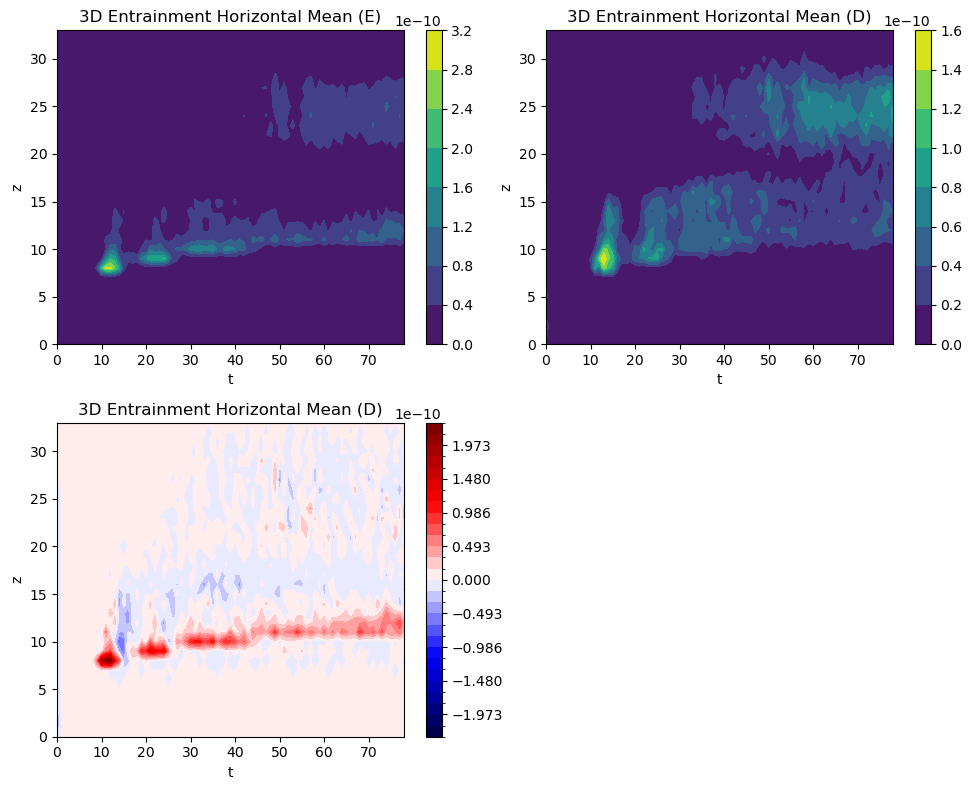

In [45]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, figure=fig)

######
cmap1 = plt.cm.viridis
cmap2 = plt.cm.seismic 
n_levels=29
######


ax1 = fig.add_subplot(gs[0, 0])
# out = np.sum(profile_array_e_c, axis=(2, 3))
out = np.mean(profile_array_e_c, axis=(2, 3))
cf1 = ax1.contourf(out.T, cmap=cmap1)
fig.colorbar(cf1, ax=ax1, orientation='vertical')
ax1.set_title('3D Entrainment Horizontal Mean (E)')
ax1.set_xlabel('t')
ax1.set_ylabel('z')

ax2 = fig.add_subplot(gs[0, 1])
# out = np.sum(profile_array_d_c, axis=(2, 3))
out = np.mean(profile_array_d_c, axis=(2, 3))
cf2 = ax2.contourf(out.T, cmap=cmap1)
fig.colorbar(cf2, ax=ax2, orientation='vertical')
ax2.set_title('3D Entrainment Horizontal Mean (D)')
ax2.set_xlabel('t')
ax2.set_ylabel('z')


ax3 = fig.add_subplot(gs[1, 0])
# out = np.sum(profile_array_e_c-profile_array_d_c, axis=(2, 3))
out = np.mean(profile_array_e_c-profile_array_d_c, axis=(2, 3))

# Normalize with a balanced vmin and vmax
profile_array_net=out
vmin=-np.max(abs(profile_array_net)); vmax=+np.max(abs(profile_array_net))
levels = np.linspace(vmin, vmax, n_levels)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)
cmap = plt.get_cmap('RdBu_r', n_levels)

cf3 = ax3.contourf(out.T, cmap=cmap2,norm=norm,levels=levels)
fig.colorbar(cf3, ax=ax3, orientation='vertical')
ax3.set_title('3D Entrainment Horizontal Mean (D)')
ax3.set_xlabel('t')
ax3.set_ylabel('z')

plt.tight_layout()

In [57]:
# fig = plt.figure(figsize=(10, 8))
# gs = GridSpec(2, 2, figure=fig)

# ax1 = fig.add_subplot(gs[0, 0])
# # out = np.sum(profile_array_e_c, axis=(0, 2))
# out = np.mean(profile_array_e_c, axis=(0, 2))
# cf1 = ax1.contourf(out, levels=50, cmap='viridis')
# fig.colorbar(cf1, ax=ax1, orientation='vertical')
# ax1.set_title('3D Entrainment x-z Mean (e)')
# ax1.set_xlabel('x')
# ax1.set_ylabel('z')

# ax2 = fig.add_subplot(gs[0, 1])
# # out = np.sum(profile_array_d_c, axis=(0, 2))
# out = np.mean(profile_array_d_c, axis=(0, 2))
# cf2 = ax2.contourf(out, levels=50, cmap='viridis')
# fig.colorbar(cf2, ax=ax2, orientation='vertical')
# ax2.set_title('3D Entrainment x-z Mean (d)')
# ax2.set_xlabel('x')
# ax2.set_ylabel('z')


# ax3 = fig.add_subplot(gs[1, 0])
# # out = np.sum(profile_array_e_c-profile_array_d_c, axis=(0, 2))
# out = np.mean(profile_array_e_c-profile_array_d_c, axis=(0, 2))
# cf3 = ax3.contourf(out, levels=50, cmap='viridis')
# fig.colorbar(cf3, ax=ax3, orientation='vertical')
# ax3.set_title('3D Entrainment x-z Mean (d)')
# ax3.set_xlabel('x')
# ax3.set_ylabel('z')

# plt.tight_layout()

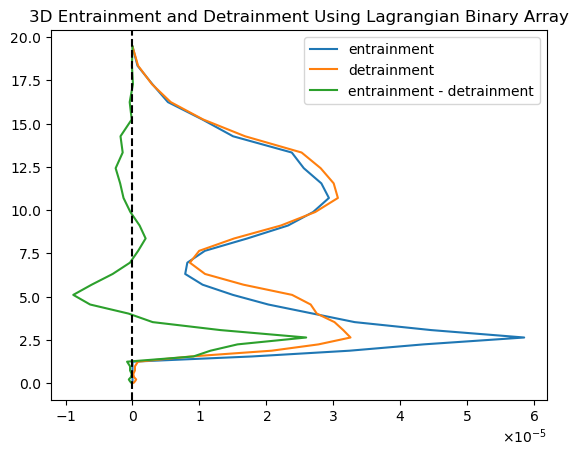

In [54]:
plt.plot(np.mean(profile_array_e_c,axis=(0,2,3))*1000**2,data['zh'],label='entrainment')
plt.plot(np.mean(profile_array_d_c,axis=(0,2,3))*1000**2,data['zh'],label='detrainment')
plt.plot(np.mean(profile_array_e_c-profile_array_d_c,axis=(0,2,3))*1000**2,data['zh'],label='entrainment - detrainment')
# dx=1000;dy=1000
# plt.plot(dx*dy*np.mean(profile_array_e_c,axis=(0,2,3)),data['zh'],label='entrainment')
# plt.plot(dx*dy*np.mean(profile_array_d_c,axis=(0,2,3)),data['zh'],label='detrainment')
# plt.plot(dx*dy*np.mean(profile_array_e_c-profile_array_d_c,axis=(0,2,3)),data['zh'],label='entrainment - detrainment')


#ATTEMPTING SUM (LIKELY NOT CORRECT)
# plt.plot(np.sum(np.mean(profile_array_e_c,axis=0),axis=(1,2)),data['zh'],label='entrainment')
# plt.plot(np.sum(np.mean(profile_array_d_c,axis=0),axis=(1,2)),data['zh'],label='detrainment')
# plt.plot(np.sum(np.mean(profile_array_e_c-profile_array_d_c,axis=0),axis=(1,2)),data['zh'],label='entrainment - detrainment')
plt.axvline(0,color='k',linestyle='dashed')

plt.legend(); plt.title('3D Entrainment and Detrainment Using Lagrangian Binary Array')

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
plt.gca().xaxis.set_major_formatter(formatter)

In [ ]:
#RESIDENCE CODE
########################################################################################################################

In [ ]:
#READING DATA BACK IN LATER

In [4]:
with h5py.File(dir2+f'lagrangian_binary_threshold.h5', 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

In [361]:
#CALCULATING RESIDENCE TIMES
#############################

In [6]:
# B=np.array([0,1,0,1,0,1,1,0,0,1,1])

# # B=1-B #for detrainment, otherwise do comment out
# print(f'binary {B}')
# cat=np.concatenate(([0], B, [0]))
# # print(f'cat {cat}')
# diff=np.diff(cat)
# print(f'diff {diff}')

In [34]:
# #CODE FOR SUBSETTING DRY ENTRAINMENT
# ind=0

# row=out_nz[ind]
# out=residence_times(row[0],'e')
# where=np.where((out[5]<=3)&(out[5]!=-100000))

# A[out[1][where],row[0]] #set to 0 

array([1])

In [9]:
def residence_times(p,type):
    B = A[:,p]

    # B=np.array([0,1,0,1,0,0,1,1,0,1,1]) #TESTING
    
    T=np.arange(len(B))
    
    if np.any(B)==True:
        if type=='e':
            B=B.copy()
        elif type=='d':
            B=1-B
    
        
        # Find the changes in the array
        changes = np.diff(np.concatenate(([0], B, [0])))  # Add 0s to detect edges
            
        start_ind = np.where(changes == 1)[0]  # Start of sequences
        end_ind = np.where(changes == -1)[0]  # End of sequences
        
        # Calculate the lengths of sequences
        lengths = end_ind - start_ind

        sequences = [(start) for start, end, length in zip(start_ind, end_ind, lengths) if length >= 1] #only records en/detrainment time
        # sequences = [(start, *range(start + 1, end+1)) for start, end, length in zip(start_ind, end_ind, lengths) if length >= 1]
        lens=[(end-start) for start, end, length in zip(start_ind, end_ind, lengths) if length >= 1] #residence times

        #Remove the last one to get rid of entrainments that reach end of simulation
        sequences=sequences[:-1];lens=lens[:-1]

        #Initial Entrainment/Detrainment Times
        ts=np.array(sequences.copy()) #only records en/detrainment time 
        # ts=np.array(tuple(item for seq in sequences for item in seq))

         #Finds Last Time Parcel is in Cloudy Updraft before Inital Entrainment
        last=[None]+[np.where(B[:ind + 1] == 1)[0][-2] for ind in ts[1:]]
        last_lens=ts[1:]-last[1:]; last_lens=np.insert(last_lens, 0, -1e5)

        if np.any(ts):
            zs=Z[ts,p]
            ys=Y[ts,p]
            xs=X[ts,p]
            return [np.array(lens),ts,zs,ys,xs,last_lens]
        else:
            return []
    else:
        return []

p=42483; out=residence_times(p,type='e')
out


[array([2, 1, 1, 1, 1]),
 array([ 8, 11, 27, 31, 38]),
 array([ 8, 12, 15, 14, 14]),
 array([68, 68, 77, 81, 87]),
 array([348, 349, 364, 367, 373]),
 array([-100000,       2,      16,       4,       7])]

Text(0.5, 1.0, 'Testing')

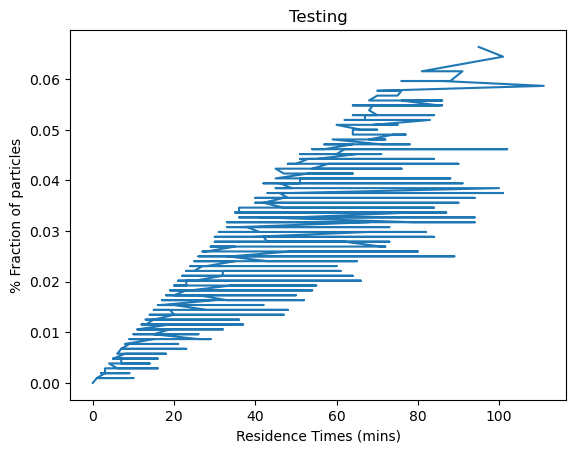

In [73]:
# #TORRI 2015 TESTING TESTING TESTING
# Nx=len(data['xh']);Ny=len(data['yh']);Nz=len(data['zh'])
# xy_array=np.zeros((Ny,Nx));xy_counter=np.zeros_like(xy_array)
# xz_array=np.zeros((Nz,Nx));xz_counter=np.zeros_like(xz_array)

# Np=125000-1
# for p in np.arange(Np): 
#     out=residence_times(p,type='e')
#     if np.any(out):
#         xy_array[out[3],out[4]]+=out[0] #add the (x,y) residence times 
#         xy_counter[out[3],out[4]]+=np.ones_like(out[0])
        
#         xz_array[out[2],out[4]]+=out[0] #add the (x,z) residence times 
#         xz_counter[out[2],out[4]]+=np.ones_like(out[0])


# one=xz_array.flatten()
# two=xz_counter.flatten()

# #SORTING
# sorted_indices = np.argsort(two)
# sorted_two = two[sorted_indices]
# sorted_one = one[sorted_indices]

# plt.plot(sorted_one,sorted_two*100/(np.sum(xz_counter)))
# plt.ylabel('% Fraction of particles');plt.xlabel('Residence Times (mins)')
# plt.title("Testing")

In [5]:
#ENTRAINMENT/DETRAINMENT PROFILES
Nx=len(data['xh']);Ny=len(data['yh']);Nz=len(data['zh'])
xy_array=np.zeros((Ny,Nx));xy_counter=np.zeros_like(xy_array)
xz_array=np.zeros((Nz,Nx));xz_counter=np.zeros_like(xz_array)

Np=125000-1
for p in np.arange(Np): 
    out=residence_times(p,type='e')
    

    if np.any(out):
        # #TESTING. ONLY STORING PRECONDITIONS PARCELS
        # for ind in np.arange(6):
        #     out[ind]=out[ind][np.where(out[-1]<=2)]
        # #####

        # xy_array[out[3],out[4]]+=out[0] #add the (x,y) residence times 
        # xy_counter[out[3],out[4]]+=np.ones_like(out[0])
        np.add.at(xy_array, (out[3], out[4]), out[0])  
        np.add.at(xy_counter, (out[3], out[4]), 1)
        
        # xz_array[out[2],out[4]]+=out[0] #add the (x,z) residence times 
        # xz_counter[out[2],out[4]]+=np.ones_like(out[0])
        np.add.at(xz_array, (out[2], out[4]), out[0])  # Add residence times to (x, z) positions
        np.add.at(xz_counter, (out[2], out[4]), 1)


#Divide by Counts
mask = xy_counter != 0
xy_array[mask]/=xy_counter[mask]
mask = xz_counter != 0
xz_array[mask]/=xz_counter[mask]

#Convert to Minutes
mins=((data['time'][1]-data['time'][0])/1e9/60).item()
xy_array*=mins
xz_array*=mins

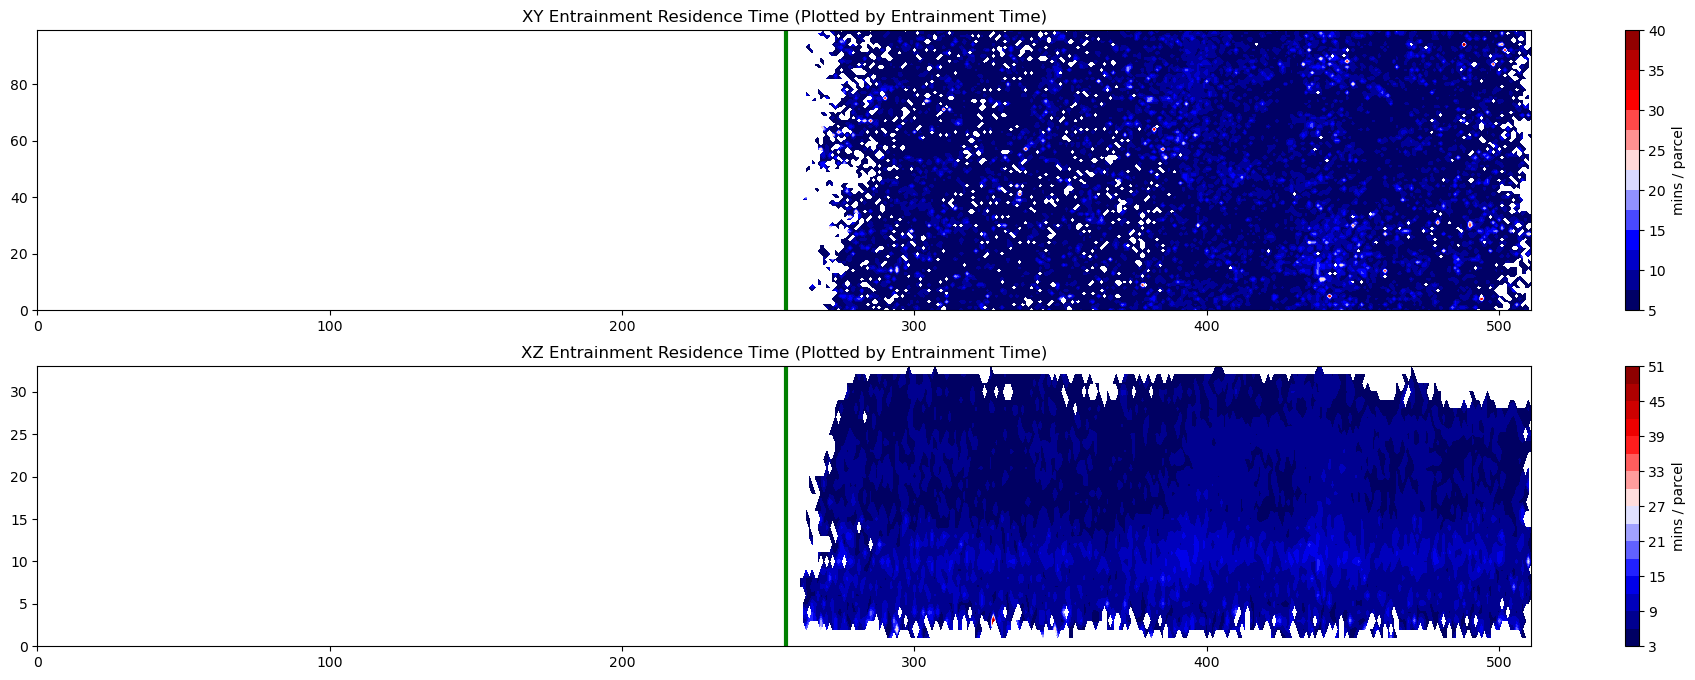

In [7]:
xy_array[xy_array==0]=np.nan
xz_array[xz_array==0]=np.nan

fig = plt.figure(figsize=(8*(512/34)/5, 8))
gs = gridspec.GridSpec(2, 1)  # 1 row, 2 columns
cmap='seismic'
levels1=15;levels2=15

# First subplot (xy_array contour)
ax1 = fig.add_subplot(gs[0, 0])  # First column
contour1 = ax1.contourf(xy_array,levels=levels1,cmap=cmap)
cbar1 = plt.colorbar(contour1, ax=ax1);cbar1.set_label("mins / parcel")
ax1.set_title("XY Entrainment Residence Time (Plotted by Entrainment Time)")

# Second subplot (xz_array contour)
ax2 = fig.add_subplot(gs[1, 0])  # Second column
contour2 = ax2.contourf(xz_array, levels=levels2, cmap=cmap)
cbar2 = plt.colorbar(contour2, ax=ax2);cbar2.set_label("mins / parcel")
ax2.set_title("XZ Entrainment Residence Time (Plotted by Entrainment Time)")


#COASTLINE
ax1.axvline(xy_array.shape[1]/2,color='green',linewidth=3)
ax2.axvline(xy_array.shape[1]/2,color='green',linewidth=3)

#THICKEN COLOR LINES

for edge in cbar1.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(10)
for edge in cbar2.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(8)



/tmp/ipykernel_2720098/1622528860.py:9: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(xz_array[:,:],axis=(1)),data['zh'],label='everywhere')


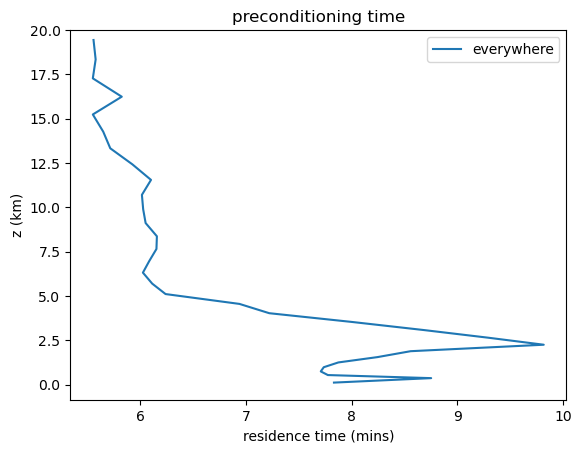

In [12]:
# currently i look for runs of being in cloudy updraft that are at least 5 minutes (1 timestep). i add the total length of that run at the location of initial entrainment/detrainment. then i average to get vertical profile. 

# For entrainment, particles should stay in a cloud for 30/60 minutes
# I’m very surprised by a) the extremely low values for entrainment time and b) the extremely high values for detainment times
# another thing: this is only cloudy updrafts, not clouds as well. is that 30/60 minutes true for the “cloud updrafts”?
# for detrainment then, there are some parcels that don’t interact with any “cloudy updrafts” for a very long time.
# also, if you look at the contour plot we do have higher values than the vertical profile 

plt.plot(np.nanmean(xz_array[:,:],axis=(1)),data['zh'],label='everywhere')
plt.ylabel('z (km)');plt.xlabel('residence time (mins)')


# plt.plot(np.nanmean(xz_array[:,int(512/2):512],axis=(1)),data['zh'],label='over land')
# plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')

# plt.plot(np.nanmean(xz_array[:,0:int(512/2)],axis=(1)),data['zh'],label='over ocean')
# plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')

plt.ylim(top=20)
plt.title('preconditioning time')
plt.legend()

In [25]:
#PRECONDITIONING TIMES
#ENTRAINMENT/DETRAINMENT PROFILES
Nx=len(data['xh']);Ny=len(data['yh']);Nz=len(data['zh'])
xy_array=np.zeros((Ny,Nx));xy_counter=np.zeros_like(xy_array)
xz_array=np.zeros((Nz,Nx));xz_counter=np.zeros_like(xz_array)

Np=125000-1
for p in np.arange(Np): 
# for p in out_nz[:,0]: #FOR OUT_NZ
    out=residence_times(p,type='e')
    

    if np.any(out):
        out=[arr[1:] for arr in out] #TESTING

        #TESTING. ONLY STORING PRECONDITIONS PARCELS
        # for ind in np.arange(6):
        #     out[ind]=out[ind][np.where(out[-1]<=2)]
        ######

        # xy_array[out[3],out[4]]+=out[0] #add the (x,y) residence times 
        # xy_counter[out[3],out[4]]+=np.ones_like(out[0])
        np.add.at(xy_array, (out[3], out[4]), out[-1])  
        np.add.at(xy_counter, (out[3], out[4]), 1)
        
        # xz_array[out[2],out[4]]+=out[0] #add the (x,z) residence times 
        # xz_counter[out[2],out[4]]+=np.ones_like(out[0])
        np.add.at(xz_array, (out[2], out[4]), out[-1])  # Add residence times to (x, z) positions
        np.add.at(xz_counter, (out[2], out[4]), 1)


#Divide by Counts
mask = xy_counter != 0
xy_array[mask]/=xy_counter[mask]
mask = xz_counter != 0
xz_array[mask]/=xz_counter[mask]

#Convert to Minutes
mins=((data['time'][1]-data['time'][0])/1e9/60).item()
xy_array*=mins
xz_array*=mins

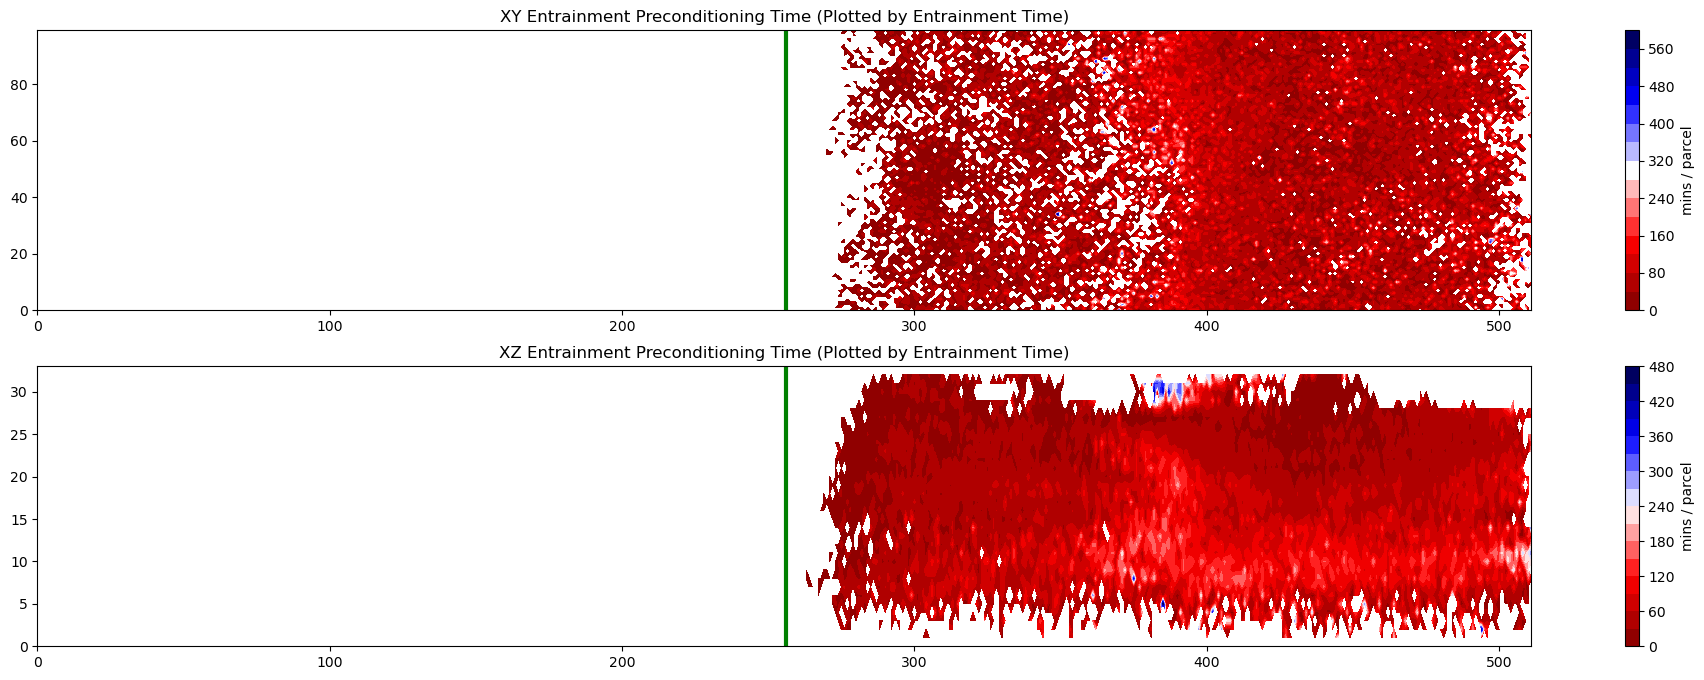

In [26]:
xy_array[xy_array==0]=np.nan
xz_array[xz_array==0]=np.nan

fig = plt.figure(figsize=(8*(512/34)/5, 8))
gs = gridspec.GridSpec(2, 1)  # 1 row, 2 columns
cmap='seismic_r'
levels1=15;levels2=15

# First subplot (xy_array contour)
ax1 = fig.add_subplot(gs[0, 0])  # First column
contour1 = ax1.contourf(xy_array,levels=levels1,cmap=cmap)
cbar1 = plt.colorbar(contour1, ax=ax1);cbar1.set_label("mins / parcel")
ax1.set_title("XY Entrainment Preconditioning Time (Plotted by Entrainment Time)")

# Second subplot (xz_array contour)
ax2 = fig.add_subplot(gs[1, 0])  # Second column
contour2 = ax2.contourf(xz_array, levels=levels2, cmap=cmap)
cbar2 = plt.colorbar(contour2, ax=ax2);cbar2.set_label("mins / parcel")
ax2.set_title("XZ Entrainment Preconditioning Time (Plotted by Entrainment Time)")


#COASTLINE
ax1.axvline(xy_array.shape[1]/2,color='green',linewidth=3)
ax2.axvline(xy_array.shape[1]/2,color='green',linewidth=3)

#THICKEN COLOR LINES

for edge in cbar1.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(10)
for edge in cbar2.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(8)



/tmp/ipykernel_2720098/956800355.py:9: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(xz_array[:,:],axis=(1)),data['zh'],label='everywhere')


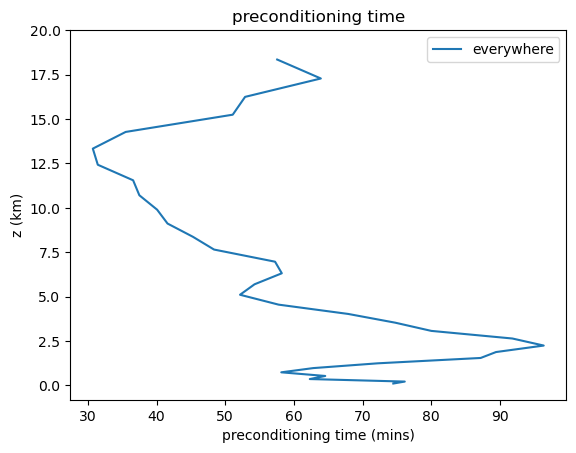

In [28]:
# currently i look for runs of being in cloudy updraft that are at least 5 minutes (1 timestep). i add the total length of that run at the location of initial entrainment/detrainment. then i average to get vertical profile. 

# For entrainment, particles should stay in a cloud for 30/60 minutes
# I’m very surprised by a) the extremely low values for entrainment time and b) the extremely high values for detainment times
# another thing: this is only cloudy updrafts, not clouds as well. is that 30/60 minutes true for the “cloud updrafts”?
# for detrainment then, there are some parcels that don’t interact with any “cloudy updrafts” for a very long time.
# also, if you look at the contour plot we do have higher values than the vertical profile 

plt.plot(np.nanmean(xz_array[:,:],axis=(1)),data['zh'],label='everywhere')
plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')


# plt.plot(np.nanmean(xz_array[:,int(512/2):512],axis=(1)),data['zh'],label='over land')
# plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')

# plt.plot(np.nanmean(xz_array[:,0:int(512/2)],axis=(1)),data['zh'],label='over ocean')
# plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')

plt.ylim(top=20)
plt.title('preconditioning time')
plt.legend()

In [365]:
# #TESTING TESTING TESTING *&*&*&*&
# #PRECONDITION FOR CL INTERACTION 


# #MAKE PROFILE ARRAY
# zhs=data['zh'].values
# profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
# profile_array[:,2]=zhs

# #COMPUTE
# mins=((data['time'][1]-data['time'][0])/1e9/60).item()
# for ind in np.arange(out_nz.shape[0]):
#     row=out_nz[ind]
    
#     previous=A[:,row[0]][:row[4]]
#     CL_z=Z[row[4],row[0]]
#     if np.any(previous)==True:
#         last=np.where(previous==1)[0][-1]
#         last_len=row[4]-last
#         last_len_mins=last_len*mins
        
#         #ADD TO PROFILE ARRAY
#         profile_array[CL_z,0]+=last_len*mins
#         profile_array[CL_z,1]+=1

    
#    #*&*&

# def averaged_profiles(profile): 
#     out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
#     out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
#     return out_var
# avg_profile_array=averaged_profiles(profile_array)

# plt.plot(avg_profile_array[:,0],avg_profile_array[:,1]*1000)
# plt.xlabel('t (mins)');plt.ylabel('z (m)')
# plt.title('Testing. When was parcel last in cloudy updraft before hitting CL')

In [19]:
Nx=len(data['xh']);Ny=len(data['yh']);Nz=len(data['zh'])
xy_array=np.zeros((Ny,Nx));xy_counter=np.zeros_like(xy_array)
xz_array=np.zeros((Nz,Nx));xz_counter=np.zeros_like(xz_array)

Np=125000-1
for p in np.arange(Np): 
    out=residence_times(p,type='d')
    if np.any(out):
        
        # xy_array[out[3],out[4]]+=out[0] #add the (x,y) residence times 
        # xy_counter[out[3],out[4]]+=np.ones_like(out[0])
        np.add.at(xy_array, (out[3], out[4]), out[0])  
        np.add.at(xy_counter, (out[3], out[4]), 1)
        
        # xz_array[out[2],out[4]]+=out[0] #add the (x,z) residence times 
        # xz_counter[out[2],out[4]]+=np.ones_like(out[0])
        np.add.at(xz_array, (out[2], out[4]), out[0])  # Add residence times to (x, z) positions
        np.add.at(xz_counter, (out[2], out[4]), 1)


#Divide by Counts
mask = xy_counter != 0
xy_array[mask]/=xy_counter[mask]
mask = xz_counter != 0
xz_array[mask]/=xz_counter[mask]


#Convert to Minutes
mins=((data['time'][1]-data['time'][0])/1e9/60).item()
xy_array*=mins
xz_array*=mins

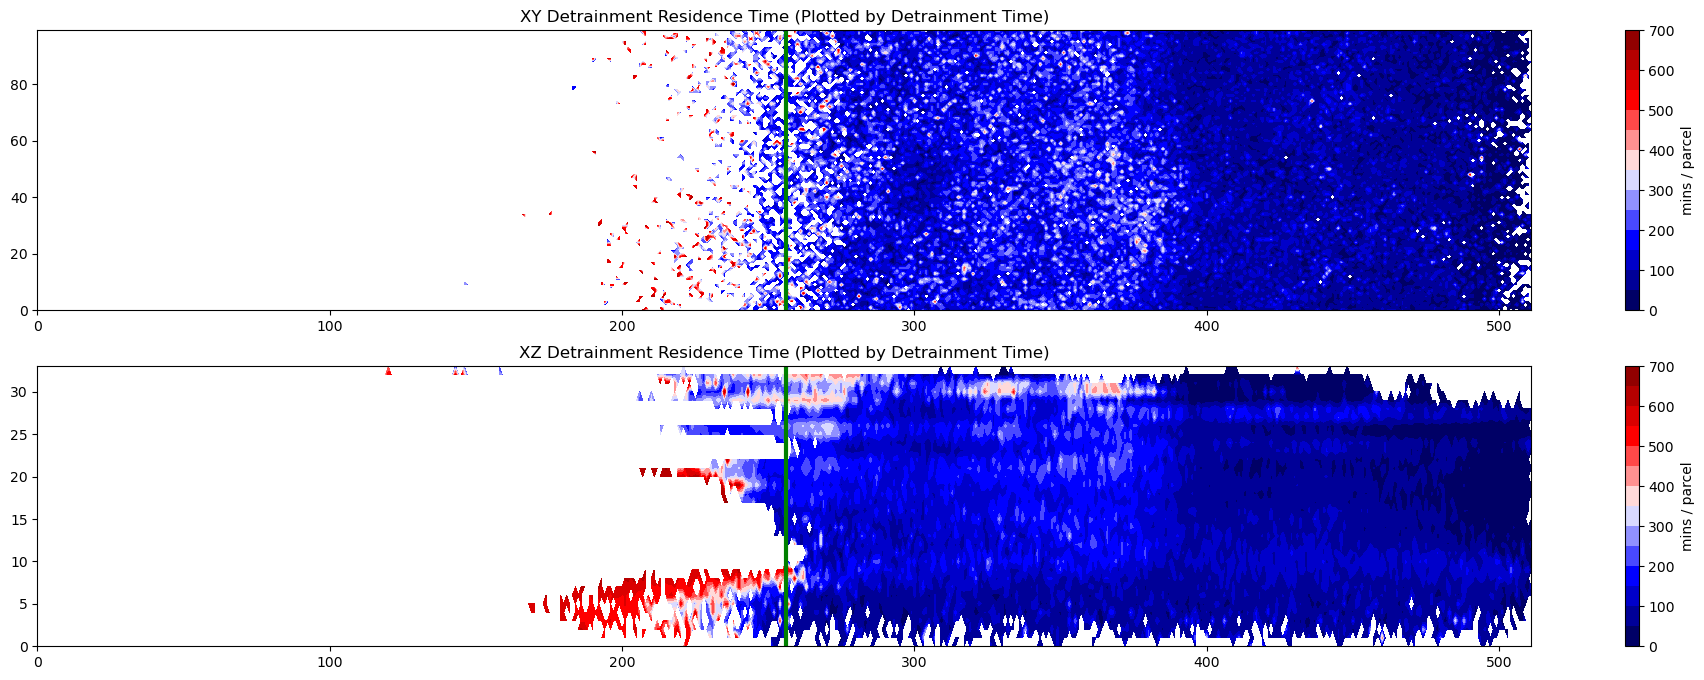

In [20]:
xy_array[xy_array==0]=np.nan
xz_array[xz_array==0]=np.nan

fig = plt.figure(figsize=(8*(512/34)/5, 8))
gs = gridspec.GridSpec(2, 1)  # 1 row, 2 columns
cmap='seismic'
levels1=15;levels2=15

# First subplot (xy_array contour)
ax1 = fig.add_subplot(gs[0, 0])  # First column
contour1 = ax1.contourf(xy_array,levels=levels1,cmap=cmap)
cbar1 = plt.colorbar(contour1, ax=ax1);cbar1.set_label("mins / parcel")
ax1.set_title("XY Detrainment Residence Time (Plotted by Detrainment Time)")

# Second subplot (xz_array contour)
ax2 = fig.add_subplot(gs[1, 0])  # Second column
contour2 = ax2.contourf(xz_array, levels=levels2, cmap=cmap)
cbar2 = plt.colorbar(contour2, ax=ax2);cbar2.set_label("mins / parcel")
ax2.set_title("XZ Detrainment Residence Time (Plotted by Detrainment Time)")


#COASTLINE
ax1.axvline(xy_array.shape[1]/2,color='green',linewidth=3)
ax2.axvline(xy_array.shape[1]/2,color='green',linewidth=3)

#THICKEN COLOR LINES

for edge in cbar1.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(10)
for edge in cbar2.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(8)



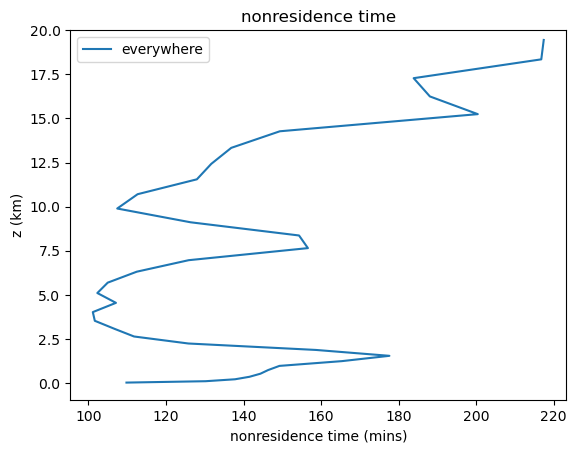

In [22]:
# currently i look for runs of being in cloudy updraft that are at least 5 minutes (1 timestep). i add the total length of that run at the location of initial entrainment/detrainment. then i average to get vertical profile. 

# For entrainment, particles should stay in a cloud for 30/60 minutes
# I’m very surprised by a) the extremely low values for entrainment time and b) the extremely high values for detainment times
# another thing: this is only cloudy updrafts, not clouds as well. is that 30/60 minutes true for the “cloud updrafts”?
# for detrainment then, there are some parcels that don’t interact with any “cloudy updrafts” for a very long time.
# also, if you look at the contour plot we do have higher values than the vertical profile 

plt.plot(np.nanmean(xz_array[:,:],axis=(1)),data['zh'],label='everywhere')
plt.ylabel('z (km)');plt.xlabel('nonresidence time (mins)')


# plt.plot(np.nanmean(xz_array[:,int(512/2):512],axis=(1)),data['zh'],label='over land')
# plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')

# plt.plot(np.nanmean(xz_array[:,0:int(512/2)],axis=(1)),data['zh'],label='over ocean')
# plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')

plt.ylim(top=20)
plt.title('nonresidence time')
plt.legend()

In [180]:
# Loading Important Variables
##############
if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    buoyancy_data=data['buoyancy'].data

    import h5py
    with h5py.File(dir + 'Variable_Calculation/' + 'theta_e'+f'_{res}'+'.h5', 'r') as f:
        theta_e_data = f['theta_e'][:]
    
    print('done')
    empty_like=True

loading neccessary variables
done


In [ ]:
#IMPORTANT FOR PLOTTING

# xticks/yticks
# xticks = plt.gca().get_xticks()
# new_labels = [str(int(tick * 5)) for tick in xticks]
# plt.gca().set_xticklabels(new_labels);

# cbar-ticks
# cbar_ticks = cbar.get_ticks()  # Get the current ticks
# new_ticks = [str(int(tick * 5)) for tick in cbar_ticks]  # Modify ticks (multiply by 5 and convert to string)
# cbar.set_ticks(cbar_ticks)  # Set the original ticks again to avoid resetting
# cbar.set_ticklabels(new_ticks)


#imshow
# plt.yticks(np.arange(Nz))
# new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
# plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)

In [ ]:
#MAKING 2D HISTOGRAM OF RESIDENCE TIME VS Z (COLOR: VARIABLE)

In [10]:
def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

In [31]:
lst=[]
for p in np.arange(Np):
    out=residence_times(p,type='e')
    if np.any(out)==True:
        lens=out[0]
        lst.append(lens)
print(f'max entrainment time: {max(lst)}')

max entrainment time: [14]


In [198]:
Nz=len(data['zh'])
profile=np.zeros((Nz,18)); #residence time by Z levels
counter=np.zeros_like(profile)

Np=125000-1
for p in np.arange(Np):
    out=residence_times(p,type='e')
    if np.any(out)==True:
        lens=out[0]
        # print(lens)
        
        ts=out[1]
        zs=out[2]
        ys=out[3]
        xs=out[4]

        for ind,(z,l) in enumerate(zip(zs,lens)):
            profile[z,l]+=1

# #NORMALIZATION
row_averages = np.nansum(profile, axis=1)
mask = row_averages!=0
profile[mask] /= row_averages[mask,np.newaxis]


/tmp/ipykernel_567860/3155184634.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels);


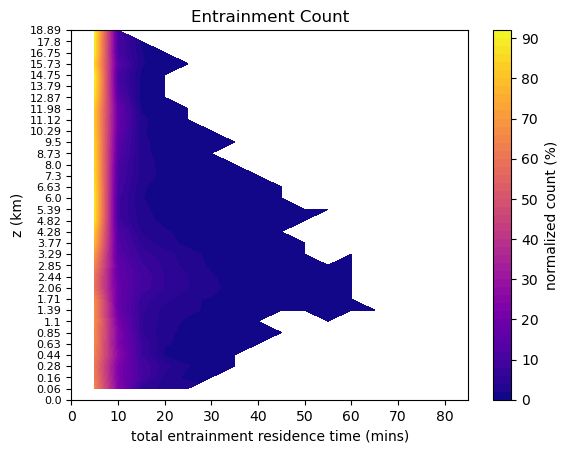

In [199]:
residence_profile=profile.copy() #save for comparing with TKE later


#Nan out zeros
cmap='plasma'
profile2=profile.copy()
profile2[profile2==0]=np.nan


#PLOTTING
# plt.imshow(profile.T);plt.gca().invert_yaxis()
plt.contourf(profile2*100,cmap=cmap,levels=50)

cbar=plt.colorbar(label='normalized count (%)')
plt.ylabel('z (km)');plt.xlabel('total entrainment residence time (mins)')
plt.title('Entrainment Count')

#FIXING TICKS

plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);


In [95]:
with h5py.File(dir+f'lagrangian_binary_threshold.h5', 'r') as f:
    # Load the dataset by its name
    A = f['A'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

In [177]:
Nz=len(data['zh'])
profile=np.zeros((Nz,18)); #residence time by Z levels
counter=np.zeros_like(profile)

Np=125000-1
for p in np.arange(Np):
    out=residence_times(p,type='e')
    if np.any(out)==True:
        lens=out[0]
        # print(lens)
        
        ts=out[1]
        zs=out[2]
        ys=out[3]
        xs=out[4]

        
        for ind,(z,l) in enumerate(zip(zs,lens)):
            profile[z,l]+=w_data[ts[ind],zs[ind],ys[ind],xs[ind]]
            counter[z,l]+=1

#averaging by number of parcel
mask=profile!=0
profile[mask]/=counter[mask]

/tmp/ipykernel_567860/12529725.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels);


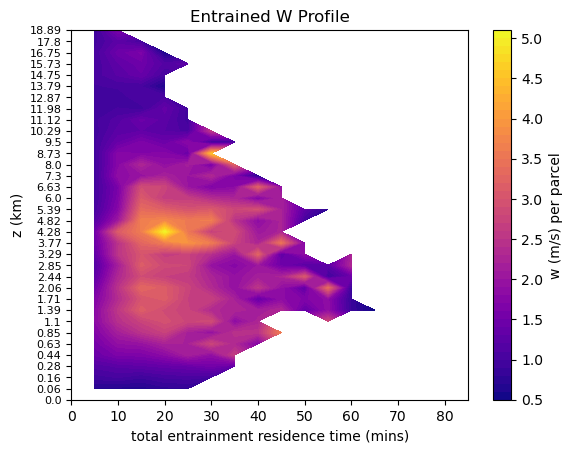

In [178]:
cmap='plasma'
profile[profile==0]=np.nan
plt.contourf(profile,cmap=cmap,levels=50)
plt.colorbar(label='w (m/s) per parcel')
plt.xlabel('total entrainment residence time (mins)');plt.ylabel('z (km)')
plt.title('Entrained W Profile')

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);


plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);

In [181]:
Nz=len(data['zh'])
profile=np.zeros((Nz,18)); #residence time by Z levels
counter=np.zeros_like(profile)

Np=125000-1
for p in np.arange(Np):
    out=residence_times(p,type='e')
    if np.any(out)==True:
        lens=out[0]
        # print(lens)
        
        ts=out[1]
        zs=out[2]
        ys=out[3]
        xs=out[4]

        
        for ind,(z,l) in enumerate(zip(zs,lens)):
            profile[z,l]+=theta_e_data[ts[ind],zs[ind],ys[ind],xs[ind]]
            counter[z,l]+=1

#averaging by number of parcel
mask=profile!=0
profile[mask]/=counter[mask]

/tmp/ipykernel_567860/3886817416.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels);


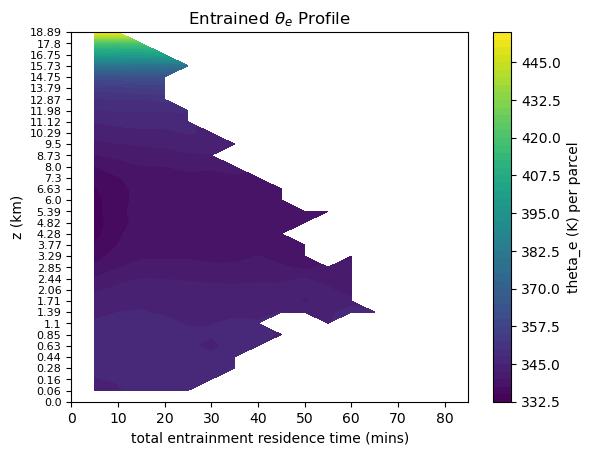

In [186]:
cmap='viridis'
profile[profile==0]=np.nan

plt.contourf(profile,cmap=cmap,levels=50)#,vmin=200)
plt.colorbar(label='theta_e (K) per parcel')
plt.xlabel('total entrainment residence time (mins)');plt.ylabel('z (km)')
plt.title(r'Entrained $\theta_e$ Profile')

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);

plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);


In [187]:
#Loading Some Data
tke_data=data['tke'].interp(zf=data['zh']).data

In [194]:
Nz=len(data['zh'])
profile=np.zeros((Nz,18)); #residence time by Z levels
counter=np.zeros_like(profile)

Np=125000-1
for p in np.arange(Np):
    out=residence_times(p,type='e')
    if np.any(out)==True:
        lens=out[0]
        # print(lens)
        
        ts=out[1]
        zs=out[2]
        ys=out[3]
        xs=out[4]

        
        for ind,(z,l) in enumerate(zip(zs,lens)):
            profile[z,l]+=tke_data[ts[ind],zs[ind],ys[ind],xs[ind]]
            counter[z,l]+=1

#averaging by number of parcel
mask=profile!=0
profile[mask]/=counter[mask]

/tmp/ipykernel_567860/480028002.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels);


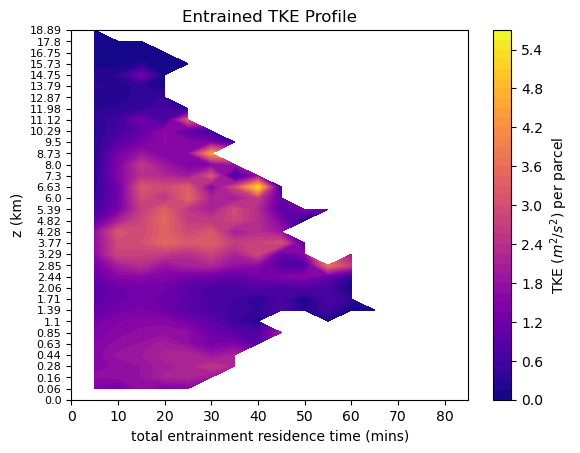

In [195]:
TKE_profile=profile.copy()

cmap='plasma'
profile[profile==0]=np.nan

plt.contourf(profile,cmap=cmap, levels=50)
plt.colorbar(label=r'TKE ($m^2/s^2$) per parcel')
plt.xlabel('total entrainment residence time (mins)');plt.ylabel('z (km)')
plt.title('Entrained TKE Profile')

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);

plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);

/tmp/ipykernel_567860/1324642050.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels);


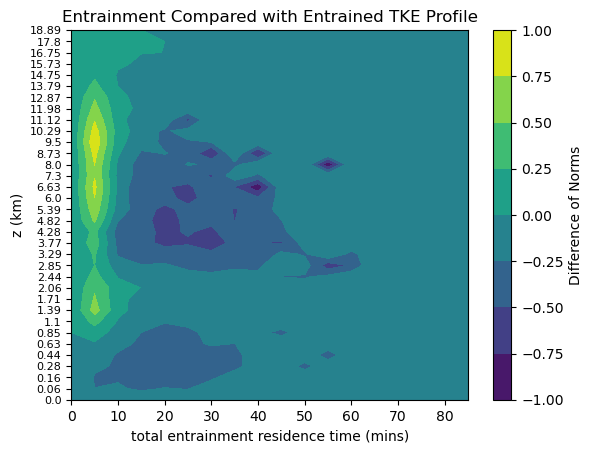

In [197]:
#TESTING TESTING TESTING


TKE_norm = (TKE_profile - np.min(TKE_profile)) / (np.max(TKE_profile) - np.min(TKE_profile))
residence_norm = (residence_profile - np.min(residence_profile)) / (np.max(residence_profile) - np.min(residence_profile))

compare_array = (1-TKE_norm) - (1-residence_norm)



plt.contourf(compare_array)
plt.colorbar(label='Difference of Norms')
plt.xlabel('total entrainment residence time (mins)');plt.ylabel('z (km)')
plt.title('Entrainment Compared with Entrained TKE Profile')

####

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);

plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);